In [191]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from numpy.lib.stride_tricks import sliding_window_view

In [192]:
def sigmoid(Z):
    """
    Implements the sigmoid activation in numpy
    
    Arguments:
    Z -- numpy array of any shape
    
    Returns:
    A -- output of sigmoid(z), same shape as Z
    cache -- returns Z as well, useful during backpropagation
    """
    
    A = 1/(1+np.exp(-Z))
    cache = Z
    
    return A, cache

In [193]:
def relu(Z):
    """
    Implement the RELU function.

    Arguments:
    Z -- Output of the linear layer, of any shape

    Returns:
    A -- Post-activation parameter, of the same shape as Z
    cache -- a python dictionary containing "A" ; stored for computing the backward pass efficiently
    """

    A = np.maximum(0,Z)
    
    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache

In [194]:
def tanh(Z):
    
    A = np.tanh(Z)

    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache

In [195]:
def tanh_backward(dA, cache):
    
    Z = cache
    A = np.tanh(Z)
    dZ = dA * (1 - A**2)

    assert(dZ.shape == Z.shape)

    return dZ

In [196]:
def relu_backward(dA, cache):
    """
    Implement the backward propagation for a single RELU unit.

    Arguments:
    dA -- post-activation gradient, of any shape
    cache -- 'Z' where we store for computing backward propagation efficiently

    Returns:
    dZ -- Gradient of the cost with respect to Z
    """
 
    Z = cache
    dZ = np.array(dA, copy=True) # just converting dz to a correct object.

    # When z <= 0, you should set dz to 0 as well. 
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ

In [197]:
def sigmoid_backward(dA, cache):
    """
    Implement the backward propagation for a single SIGMOID unit.

    Arguments:
    dA -- post-activation gradient, of any shape
    cache -- 'Z' where we store for computing backward propagation efficiently

    Returns:
    dZ -- Gradient of the cost with respect to Z
    """
    
    Z = cache

    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    assert (dZ.shape == Z.shape)
    
    return dZ

In [198]:
def load_split_dataset(mat_path, compression='regular'):

    signal_data = loadmat(mat_path)
    
    if compression == 'regular':
        X, y = signal_data['train_input_real'], signal_data['train_output_real']

        a = X.ravel()
        window = 16
        pad = window - 1

        a_padded = np.pad(a, (pad, 0), constant_values=0)

        all_windows = sliding_window_view(a_padded, window_shape=window, axis=0)

        X = all_windows[:20032]

        X_train, X_test, y_train, y_test = train_test_split(X, y)

        # Scale X (per feature/column)
        X_mean = np.mean(X_train, axis=0, keepdims=True)
        X_std = np.std(X_train, axis=0, keepdims=True) + 1e-8  # avoid div by zero
        X_train_scaled = (X_train - X_mean) / X_std
        X_test_scaled = (X_test - X_mean) / X_std  # use train mean/std to scale test

        # Scale y (per output dimension)
        y_mean = np.mean(y_train, axis=0, keepdims=True)
        y_std = np.std(y_train, axis=0, keepdims=True) + 1e-8
        y_train_scaled = (y_train - y_mean) / y_std
        y_test_scaled = (y_test - y_mean) / y_std

        # Return scaled data and scaling parameters for inverse transform if needed
        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, (X_mean, X_std, y_mean, y_std)
    
    elif compression == 'none':
        X, y = signal_data['X_chirpData'], signal_data['X_chirpData']
        X = X.T
        y = y.T

        X_train, X_test, y_train, y_test = train_test_split(X, y)

    elif compression == 'simple':
        X, y = signal_data['X_chirpData'], signal_data['y_chirpData']
        X = X.T
        y = y.T

        X_train, X_test, y_train, y_test = train_test_split(X, y)

    return X_train, X_test, y_train, y_test

    

In [199]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer
    
    Returns:
    parameters -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """
    
    np.random.seed(1)
    
    W1 = np.random.randn(n_h, n_x)* np.sqrt(2. / n_x)
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h)* np.sqrt(2. / n_h)
    b2 = np.zeros((n_y, 1))

    assert(W1.shape == (n_h, n_x))
    assert(b1.shape == (n_h, 1))
    assert(W2.shape == (n_y, n_h))
    assert(b2.shape == (n_y, 1))
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [200]:
def initialize_parameters_deep(layer_dims):
    """
    Arguments:
    layer_dims -- python array (list) containing the dimensions of each layer in our network
    
    Returns:
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
    """
    
    np.random.seed(1)
    parameters = {}
    L = len(layer_dims)            # number of layers in the network

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(layer_dims[l-1]) #*0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l-1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

        
    return parameters

In [201]:
def linear_forward(A, W, b):
    """
    Implement the linear part of a layer's forward propagation.

    Arguments:
    A -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)

    Returns:
    Z -- the input of the activation function, also called pre-activation parameter 
    cache -- a python dictionary containing "A", "W" and "b" ; stored for computing the backward pass efficiently
    """
    
    Z = np.dot(W, A) + b

    assert(Z.shape == (W.shape[0], A.shape[1]))
    cache = (A, W, b)
    
    return Z, cache

In [202]:
def linear_activation_forward(A_prev, W, b, activation):
    """
    Implement the forward propagation for the LINEAR->ACTIVATION layer

    Arguments:
    A_prev -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

    Returns:
    A -- the output of the activation function, also called the post-activation value 
    cache -- a python dictionary containing "linear_cache" and "activation_cache";
             stored for computing the backward pass efficiently
    """
    
    if activation == "sigmoid":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)
    
    elif activation == "relu":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = relu(Z)
        
    elif activation == "tanh":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = tanh(Z)

    elif activation == 'linear':
        Z, linear_cache = linear_forward(A_prev, W, b)
        A = Z
        activation_cache = Z

    else:
        print("\033[91mError! Please make sure you have passed the value correctly in the \"activation\" parameter")
    
    assert (A.shape == (W.shape[0], A_prev.shape[1]))
    cache = (linear_cache, activation_cache)

    return A, cache

In [203]:
def L_model_forward(X, parameters):
    """
    Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->RELU computation
    
    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()
    
    Returns:
    AL -- last post-activation value
    caches -- list of caches containing:
                every cache of linear_relu_forward() (there are L-1 of them, indexed from 0 to L-2)
                the cache of linear_sigmoid_forward() (there is one, indexed L-1)
    """

    caches = []
    A = X
    L = len(parameters) // 2                  # number of layers in the neural network
    
    # Implement [LINEAR -> RELU]*(L-1). Add "cache" to the "caches" list.
    for l in range(1, L):
        A_prev = A 
        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], activation = "relu")
        caches.append(cache)
    
    # Implement LINEAR -> RELU. Add "cache" to the "caches" list.
    AL, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], activation = "linear")
    caches.append(cache)

    #assert(AL.shape == (1,X.shape[1]))
            
    return AL, caches

In [204]:
def compute_cost(AL, Y):
    """
    Computes Mean Squared Error cost for regression.
    AL -- predicted values, shape (output_size, number of examples)
    Y -- true values, same shape as AL
    """
    m = Y.shape[1]
    cost = (1 / (2 * m)) * np.sum((AL - Y) ** 2)
    return np.squeeze(cost)

In [205]:
def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = 1./m * np.dot(dZ,A_prev.T)
    db = 1./m * np.sum(dZ, axis = 1, keepdims = True)
    dA_prev = np.dot(W.T,dZ)
    
    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)
    
    return dA_prev, dW, db

In [206]:
def linear_activation_backward(dA, cache, activation):
    """
    Implement the backward propagation for the LINEAR->ACTIVATION layer.
    
    Arguments:
    dA -- post-activation gradient for current layer l 
    cache -- tuple of values (linear_cache, activation_cache) we store for computing backward propagation efficiently
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"
    
    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    linear_cache, activation_cache = cache
    
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
        
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
        
    elif activation == "tanh":
        dZ = tanh_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    elif activation == 'linear':
        dZ = dA
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
    
    else:
        print("\033[91mError! Please make sure you have passed the value correctly in the \"activation\" parameter")
    
    return dA_prev, dW, db

In [207]:
def L_model_backward(AL, Y, caches):
    """
    Implement the backward propagation for the [LINEAR->RELU] * (L-1) -> LINEAR -> SIGMOID group
    
    Arguments:
    AL -- probability vector, output of the forward propagation (L_model_forward())
    Y -- true "label" vector
    caches -- list of caches containing:
                every cache of linear_activation_forward() with "relu" (there are (L-1) or them, indexes from 0 to L-2)
                the cache of linear_activation_forward() with "sigmoid" (there is one, index L-1)
    
    Returns:
    grads -- A dictionary with the gradients
             grads["dA" + str(l)] = ... 
             grads["dW" + str(l)] = ...
             grads["db" + str(l)] = ... 
    """
    grads = {}
    L = len(caches) # the number of layers
    m = AL.shape[1]
    #Y = Y.reshape(AL.shape) # after this line, Y is the same shape as AL
    
    # Initializing the backpropagation
    dAL = AL - Y
    
    # Lth layer (SIGMOID -> LINEAR) gradients. Inputs: "AL, Y, caches". Outputs: "grads["dAL"], grads["dWL"], grads["dbL"]
    current_cache = caches[L-1]
    grads["dA" + str(L-1)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(dAL, current_cache, activation = "linear")
    
    for l in reversed(range(L-1)):
        # lth layer: (RELU -> LINEAR) gradients.
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, activation = "relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads

In [208]:
def update_parameters(parameters, grads, learning_rate):
    """
    Update parameters using gradient descent
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    grads -- python dictionary containing your gradients, output of L_model_backward
    
    Returns:
    parameters -- python dictionary containing your updated parameters 
                  parameters["W" + str(l)] = ... 
                  parameters["b" + str(l)] = ...
    """
    
    L = len(parameters) // 2 # number of layers in the neural network

    # Update rule for each parameter. Use a for loop.
    for l in range(L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]
        
    return parameters

In [209]:
def clip_gradients(grads, max_norm=5.0):
    for key in grads:
        grad = grads[key]
        norm = np.linalg.norm(grad)
        if norm > max_norm:
            grads[key] = grad * max_norm / (norm + 1e-6)
    return grads

In [210]:
def two_layer_model(X, Y, layers_dims, learning_rate=0.0075, num_iterations=3000, print_cost=False):
    """
    Implements a two-layer neural network: LINEAR->RELU->LINEAR->SRELU.
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (n_y, number of examples)
    layers_dims -- dimensions of the layers (n_x, n_h, n_y)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- If set to True, this will print the cost every 100 iterations 
    
    Returns:
    parameters -- a dictionary containing W1, W2, b1, and b2
    """

    np.random.seed(1)
    grads = {}
    costs = []                        # keep track of cost
    m = X.shape[1]                    # num of examples
    (n_x, n_h, n_y) = layers_dims

    # Initialize parameters dictionary
    parameters = initialize_parameters(n_x, n_h, n_y)

    # Get parameters from dictionary
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

    # Gradient descent loop
    for i in range(0, num_iterations):

        # Forward prop LINEAR -> RELU -> LINEAR -> RELU
        A1, cache1 = linear_activation_forward(X, W1, b1, 'relu')
        A2, cache2 = linear_activation_forward(A1, W2, b2, 'linear')

        # Compute cost
        cost = compute_cost(A2, Y)

        # Initialize backward prop
        dA2 = A2 - Y
        
        # Backward prop
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, 'linear')
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, 'relu')

        # Store gradients
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2

        # Update parameters
        grads = clip_gradients(grads)
        parameters = update_parameters(parameters, grads, learning_rate)

        # Get parameters from dictionary
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]

        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 1000 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
            
    return parameters, costs

def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()


In [211]:
'''
Selection for which data to use

choice 0 is the simulated data with no compression

choice 1 is the simulated data with scalar compression by a factor of 2

choice 2 is the regular compression data
'''

choice = 2

if choice == 0:
    #simulated data no compression
    X_train, X_test, y_train, y_test = load_split_dataset('data/sim_data_out.mat', compression='none')

    #Constants defining the model
    n_x = 750
    n_h = 7
    n_y = 750
    layers_dims = (n_x, n_h, n_y)
    learning_rate = 0.0075

elif choice == 1:
    #simulated data simple compression
    X_train, X_test, y_train, y_test = load_split_dataset('data/sim_data_out.mat', compression='simple')

    #Constants defining the model
    n_x = 750
    n_h = 7
    n_y = 750
    layers_dims = (n_x, n_h, n_y)
    learning_rate = 0.0075

elif choice == 2:
    #regular data
    X_train, X_test, y_train, y_test, (X_mean, X_std, y_mean, y_std) = load_split_dataset('data/compression_data_output.mat')

    #Constants defining the model
    n_x = 16
    n_h = 7
    n_y = 1
    layers_dims = (n_x, n_h, n_y)
    learning_rate = 0.001

parameters, costs = two_layer_model(X_train.T, y_train.T, layers_dims = (n_x, n_h, n_y), num_iterations = 2, print_cost=False)

print("Cost after first iteration: " + str(costs[0]))

Cost after first iteration: 0.6765290774303382


Cost after iteration 0: 0.6765290774303382
Cost after iteration 1000: 0.042733550436352345
Cost after iteration 2000: 0.026121678099038377
Cost after iteration 3000: 0.02119329668812901
Cost after iteration 4000: 0.018556694440580418
Cost after iteration 4999: 0.016599949432140253


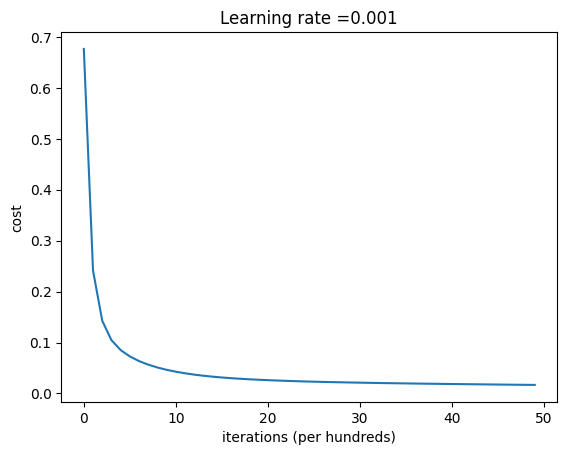

In [212]:
#5000 iterations

parameters, costs = two_layer_model(X_train.T, y_train.T, layers_dims = (n_x, n_h, n_y), num_iterations = 5000, print_cost=True)

plot_costs(costs, learning_rate)


In [213]:
#constants
layers_dims_l_layer = [16, 20, 7, 5, 1] #  4-layer model

In [214]:
def L_layer_model(X, Y, layers_dims, learning_rate = 0.01, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->LINEAR
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector, of shape (1, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1)
    costs = []                         # keep track of cost
    
    # Parameters initialization.
    parameters = initialize_parameters_deep(layers_dims)
    
    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation.
        AL, caches = L_model_forward(X, parameters)
        
        # Compute cost.
        cost = compute_cost(AL, Y)
    
        # Backward propagation.
        grads = L_model_backward(AL, Y, caches)
        
        # Update parameters.
        grads = clip_gradients(grads)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 1000 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

Cost after iteration 0: 0.5651026451596615
Cost after iteration 1000: 0.04546378191677963
Cost after iteration 2000: 0.025647423214386633
Cost after iteration 3000: 0.020363461413194308
Cost after iteration 4000: 0.01780978709744982
Cost after iteration 4999: 0.01625976943106362


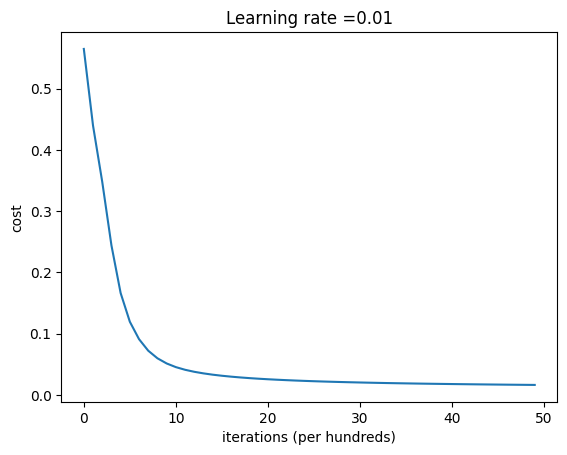

In [215]:
X_train_L_layer, X_test, y_train_L_Layer, y_test, (X_mean, X_std, y_mean, y_std) = load_split_dataset('data/compression_data_output.mat')

found_parameters, costs = L_layer_model(X_train_L_layer.T, y_train_L_Layer.T, layers_dims_l_layer, num_iterations = 5000, print_cost = True)

plot_costs(costs, learning_rate=0.01)

In [216]:
test_predictions, cache = L_model_forward(X_test.T, found_parameters)

In [217]:
train_predictions, cache = L_model_forward(X_train.T, found_parameters)

In [219]:
from scipy.io import savemat

data_to_save = {
    'X_test': X_test,
    'y_test': y_test,
    'test_predictions': test_predictions,
    'X_train': X_train,
    'y_train': y_train,
    'train_predictions': train_predictions

}

savemat('plots/decompression_data.mat', data_to_save)